In [1]:
from pathlib import Path
import IPython

def validate_results(
    metrics_dir: str = "metrics/",
    *,
    clk_mhz: float | None = None,
    exclude_pct: float = 0.0,
    show: bool = True,
    # BACKWARD-COMPAT: old single-file arg maps to core cycles
    cycles_file: str | None = "cycles_core.npy",
    # NEW: explicit dual files
    cycles_core_file: str | None = None,
    cycles_e2e_file: str | None = None,
    # Optional power traces (as saved by on_target.py)
    power_abs: str | None = "power_abs.npy",
    power_dyn: str | None = "power_dyn.npy",
) -> None:
    """
    Launch validate_results.py inside the current IPython kernel with
    the right flags for cycles(power) files.
    """
    mdir = Path(metrics_dir).expanduser().resolve()
    if not mdir.exists():
        raise FileNotFoundError(f"{mdir} does not exist")

    # Prefer explicit new params; fall back to legacy cycles_file for core.
    core_path = cycles_core_file if cycles_core_file is not None else cycles_file
    e2e_path  = cycles_e2e_file

    cli_parts = [
        "validate_results.py",
        "-m", str(mdir),
    ]

    # Map to the new, unambiguous flags
    if core_path:
        cli_parts += ["--cycles-core", core_path]
    if e2e_path:
        cli_parts += ["--cycles-e2e", e2e_path]

    # Power traces (only pass if not None)
    if power_abs:
        cli_parts += ["--power-abs", power_abs]
    if power_dyn:
        cli_parts += ["--power-dyn", power_dyn]

    if clk_mhz is not None:
        cli_parts += ["--clk-mhz", str(clk_mhz)]
    if exclude_pct > 0.0:
        cli_parts += ["--exclude-pct", str(exclude_pct)]
    if not show:
        cli_parts.append("--no-show")

    ip = IPython.get_ipython()
    if ip is None:
        raise RuntimeError("No active IPython kernel; run this from a notebook or IPython.")
    ip.run_line_magic("run", " ".join(cli_parts))


In [2]:
import tensorflow as tf, tf2onnx

model = tf.keras.models.load_model("models/keras/cnn_model.h5", compile=False)
model.summary()

sig = [tf.TensorSpec([None, 28, 28, 1], tf.float32, name="images")]  # adapt!

onnx_model, _ = tf2onnx.convert.from_keras(model,
                                           input_signature=sig,
                                           opset=18,
                                           output_path="models/onnx/cnn_model.onnx")


Model: "keras_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_3 (InputLayer)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_0 (Conv2D)                 │ (None, 26, 26, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_0 (BatchNormalization)  │ (None, 26, 26, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_0 (Activation)         │ (None, 26, 26, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_0 (MaxPooling2D)           │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 11, 11, 24)     │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 11, 11, 24)     │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 11, 11, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 5, 5, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 42)             │        25,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_0 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_act_0 (Activation)        │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 10)             │           430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Activation)     │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,558 (115.46 KB)

 Trainable params: 29,394 (114.82 KB)

 Non-trainable params: 164 (656.00 B)

In [3]:
import onnx
from onnx2pytorch import ConvertModel

# Convert ONNX model to PyTorch
pytorch_model = ConvertModel(
        onnx_model,
        experimental=True       # removes the batch-size==1 guard
)
# Save the PyTorch model
import torch
torch.save(pytorch_model.state_dict(), "models/pytorch/cnn_model.pth")
pytorch_model

c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\.venv\Lib\site-packages\onnx2pytorch\convert\layer.py:30: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  layer.weight.data = torch.from_numpy(numpy_helper.to_array(weight))
c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\.venv\Lib\site-packages\onnx2pytorch\convert\model.py:147: UserWarning: Using experimental implementation that allows 'batch_size > 1'.Batchnorm layers could potentially produce false outputs.
  warnings.warn(


ConvertModel(
  (Reshape_keras_baseline_1/bn_conv_0_1/batchnorm/mul_1__6:0): Reshape(shape=[-1  1 28 28])
  (Conv_Conv__34:0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (Relu_keras_baseline_1/conv_act_0_1/Relu:0): ReLU(inplace=True)
  (MaxPool_keras_baseline_1/pool_0_1/MaxPool2d:0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (Conv_Conv__36:0): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1))
  (Relu_keras_baseline_1/conv_act_1_1/Relu:0): ReLU(inplace=True)
  (MaxPool_keras_baseline_1/pool_1_1/MaxPool2d:0): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (Transpose_Transpose__40:0): Transpose()
  (Shape_Shape__42:0): Shape()
  (Gather_keras_baseline_1/flatten_2_1/Shape:0): Gather()
  (Cast_keras_baseline_1/flatten_2_1/Shape__22:0): Cast(dtype=torch.int32)
  (Slice_keras_baseline_1/flatten_2_1/strided_slice:0): Slice()
  (Cast_keras_baseline_1/flatten_2_1/Reshape__33:0): Cast(dtype=torch.int64)
 

In [4]:
import torchvision 

from torchvision import transforms

# Define the transformation to convert MNIST images to tensor
transform = transforms.Compose([
    transforms.ToTensor()
])

#load the MNIST dataset
mnist_dataset = torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Create a DataLoader for the dataset
mnist_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=100, shuffle=False)



In [5]:
from comp_utils.helper_functions import evaluate_model

import torch
from comp_utils.helper_functions import evaluate_model
from comp_utils.metrics_plot import (
    plot_eval_summary,
    plot_compare_latency,
    plot_compare_throughput,
)
import matplotlib.pyplot as plt

# Run evaluations
m1   = evaluate_model(pytorch_model, mnist_loader, device="dml", exclude_pct=1.0, warmup_batches=10, progress=True)


c:\Users\SagittariusA\Documents\Projects\AI_ON_FPGA_TARGET_SCRIPTS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Eval: 100%|██████████| 100/100 [00:00<00:00, 115.76it/s]

Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0354 ms ± 0.0038 (min=0.0285, max=0.0456, P50=0.0354, P90=0.0408, P99=0.0440) [batches=99]
Throughput (batch) : 28395.16 ips ± 3100.85 (P50=28257.37, P90=32697.08, P99=34637.38)
Throughput (global): 28107.19 ips (total_time=0.356s, samples=10000)


In [7]:
m_cpu  = evaluate_model(pytorch_model, mnist_loader, device="cpu", exclude_pct=1.0, progress=True)

Eval: 100%|██████████| 100/100 [00:00<00:00, 149.99it/s]

Backend            : cpu
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0194 ms ± 0.0016 (min=0.0165, max=0.0236, P50=0.0192, P90=0.0215, P99=0.0228) [batches=99]
Throughput (batch) : 51759.45 ips ± 4094.33 (P50=51966.95, P90=57078.95, P99=58123.69)
Throughput (global): 51503.25 ips (total_time=0.194s, samples=10000)


In [ ]:
for _ in  range(1):
    m_dml  = evaluate_model(pytorch_model, mnist_loader, device="dml", exclude_pct=1.0, progress=True)

Eval: 100%|██████████| 100/100 [00:00<00:00, 121.00it/s]


Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0339 ms ± 0.0033 (min=0.0282, max=0.0422, P50=0.0335, P90=0.0381, P99=0.0414) [batches=99]
Throughput (batch) : 29608.56 ips ± 2827.04 (P50=29819.59, P90=33099.58, P99=35003.23)
Throughput (global): 29380.37 ips (total_time=0.340s, samples=10000)


Eval: 100%|██████████| 100/100 [00:00<00:00, 122.33it/s]


Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0330 ms ± 0.0030 (min=0.0281, max=0.0401, P50=0.0329, P90=0.0373, P99=0.0393) [batches=99]
Throughput (batch) : 30456.49 ips ± 2815.03 (P50=30334.28, P90=34861.30, P99=35426.27)
Throughput (global): 30241.12 ips (total_time=0.331s, samples=10000)


Eval: 100%|██████████| 100/100 [00:00<00:00, 122.58it/s]


...

Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0326 ms ± 0.0034 (min=0.0278, max=0.0426, P50=0.0325, P90=0.0369, P99=0.0409) [batches=99]
Throughput (batch) : 30879.27 ips ± 3196.75 (P50=30780.60, P90=35439.64, P99=35887.01)
Throughput (global): 30584.85 ips (total_time=0.327s, samples=10000)


Eval: 100%|██████████| 100/100 [00:00<00:00, 125.36it/s]


Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0322 ms ± 0.0029 (min=0.0277, max=0.0392, P50=0.0319, P90=0.0364, P99=0.0388) [batches=99]
Throughput (batch) : 31231.48 ips ± 2836.34 (P50=31374.52, P90=35144.70, P99=35874.24)
Throughput (global): 31010.78 ips (total_time=0.322s, samples=10000)


Eval: 100%|██████████| 100/100 [00:00<00:00, 123.70it/s]

Backend            : dml
Accuracy           : 98.1600%  (9816/10000)
Latency / sample   : 0.0329 ms ± 0.0037 (min=0.0279, max=0.0455, P50=0.0328, P90=0.0376, P99=0.0436) [batches=99]
Throughput (batch) : 30641.81 ips ± 3391.47 (P50=30523.17, P90=35249.35, P99=35591.95)
Throughput (global): 30286.92 ips (total_time=0.330s, samples=10000)


[GPU1] GPU 1 BRD PWR  n=100  duration=24.958s
  idle ≈ 20.18 W  (bottom 10%)
  mean  36.67 W  ± 13.99
  min/max 17.00/64.00 W
  P50/P90/P99  29.00/62.00/64.00 W
  dyn mean above idle ≈ 16.57 W
[GPU1 util] GPU 1 UTIL  n=100  duration=24.958s
  idle ≈ 1.00 W  (bottom 10%)
  mean  10.35 W  ± 8.86
  min/max 1.00/29.00 W
  P50/P90/P99  6.00/22.00/26.03 W
  dyn mean above idle ≈ 9.35 W


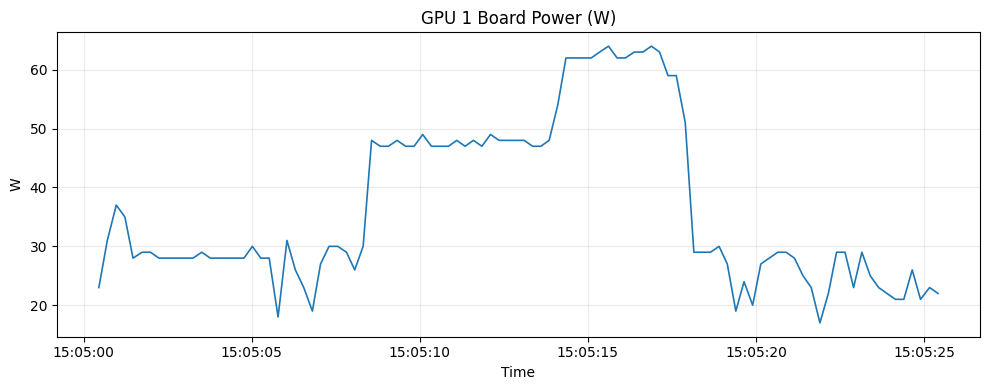

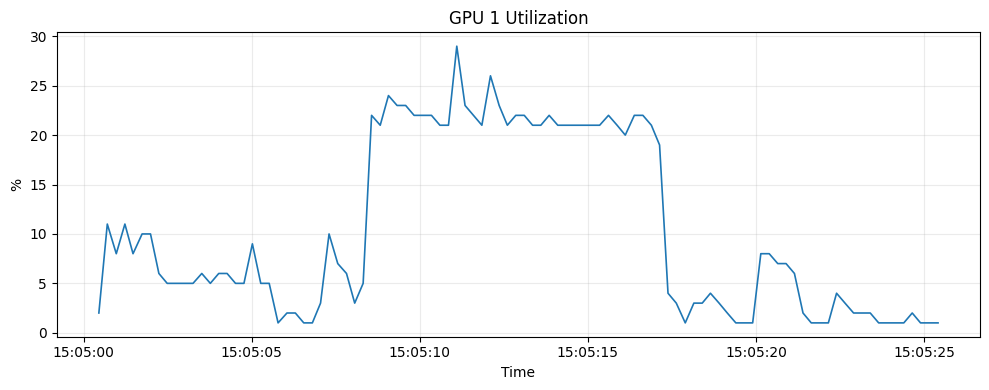

In [1]:
from comp_utils.power_plots import *

df = load_hw_csv_simple("Hardware.20251003-150525.CSV")



# GPU board power (Watts)
st_gpu = compute_idle_and_metrics(df, "GPU 1 BRD PWR", idle_seconds=5.0, idle_percentile=10.0, exclude_top_pct=1.0)
print_power_summary(st_gpu, label="GPU1")

# GPU util, CPU util work too (they're % units, but same API)
st_gpu_util = compute_idle_and_metrics(df, "GPU 1 UTIL", idle_seconds=5.0, idle_percentile=10.0)

print_power_summary(st_gpu_util, label="GPU1 util")


plot_series(df, "GPU 1 BRD PWR", title="GPU 1 Board Power (W)", ylabel="W")
plot_series(df, "GPU 1 UTIL",    title="GPU 1 Utilization",     ylabel="%")


In [3]:
#calculate the mean abs power during inference meaning when GPU utils in over 15%
import pandas as pd

df1 = load_hw_csv_simple("Hardware.20251003-150525.CSV")
df1.head()

,TIME STAMP,GPU 1 UTIL,GPU 1 BRD PWR,timestamp,t_s
1,2025-10-03 15:05:00.455,2.0,23.0,2025-10-03 15:05:00.455,0.000
2,2025-10-03 15:05:00.706,11.0,31.0,2025-10-03 15:05:00.706,0.251
3,2025-10-03 15:05:00.973,8.0,37.0,2025-10-03 15:05:00.973,0.518
4,2025-10-03 15:05:01.229,11.0,35.0,2025-10-03 15:05:01.229,0.774
5,2025-10-03 15:05:01.471,8.0,28.0,2025-10-03 15:05:01.471,1.016


In [5]:
power = df1[df1['GPU 1 UTIL'] > 15]['GPU 1 BRD PWR'].mean()
print(f"Mean GPU Power during inference: {power:.2f} W")

idle = df1[df1['GPU 1 UTIL'] < 15]['GPU 1 BRD PWR'].mean()
print(f"Mean GPU Power during idle: {idle:.2f} W")

gpu_inf_power = power - idle
print(f"Mean GPU Dynamic Power during inference: {gpu_inf_power:.2f} W")

Mean GPU Power during inference: 52.94 W
Mean GPU Power during idle: 27.91 W
Mean GPU Dynamic Power during inference: 25.04 W


In [45]:
validate_results(metrics_dir="metrics/optim", clk_mhz=200, exclude_pct=0.0)  # Validate results and generate figures

HW vs GT Accuracy        : 98.020000%
Golden vs GT Accuracy    : 98.020000%
Accuracy Δ (HW − Golden) : +0.000000 percentage points

[COMMS]
  Latency   : 0.4570 ms ± 0.0470  (min=0.4250, max=3.0290)
            : P50=0.4480  P90=0.4700  P99=0.5940
  Throughput: 2198.59 inf/s ± 116.76

[INF]
  Latency   : 0.1765 ms ± 0.0214  (min=0.1620, max=1.4430)
            : P50=0.1730  P90=0.1840  P99=0.2300
  Throughput: 5694.19 inf/s ± 298.30

[CYCLES core]   (10000 samples)
  Mean cycles : 2642 ± 1  (min=2642, max=2664)
            : P50=2642  P90=2642  P99=2642
  Mean time  : 13.210 µs (75699.20 inf/s @ 200 MHz)

[CYCLES e2e]   (10000 samples)
  Mean cycles : 13016 ± 38778  (min=10574, max=1655538)
            : P50=11214  P90=12011  P99=21409
  Mean time  : 65.079 µs (15365.89 inf/s @ 200 MHz)

[CYCLES overhead (e2e - core)]   (10000 samples)
  Mean cycles : 10374 ± 38778  (min=7932, max=1652896)
            : P50=8572  P90=9369  P99=18767
  Mean time  : 51.869 µs (19279.33 inf/s @ 200 MHz)



In [49]:
thr_gpu = 1/(0.0329/1000)
print(f"GPU Throughput: {thr_gpu:.2f} samples/sec")

efficiency_gpu = thr_gpu / power

efficiency_gpu


GPU Throughput: 30395.14 samples/sec


574.1121355823219

In [ ]:
# load the power trace